# Synthetic Controlled Datasets

This notebook runs the four artificial datasets from TODO point 5: correlated categorical embedding policy, high-cardinality categoricals, rare categories, and a sensitive identifier column.


## Setup

The synthetic datasets are deterministic and are written to `experiments/data/processed/` before exploration and experiments run.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distributions, plot_pairwise_features
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view_from_config, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.synthetic_data import SYNTHETIC_DATASETS, materialize_synthetic_datasets
from experiments.workflow import dataset_profile, load_dataset, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import vectorization_plan

SYNTHETIC_KEYS = [spec.key for spec in SYNTHETIC_DATASETS]
RESULTS_DIR = ROOT / "experiments" / "results"


In [2]:
materialize_synthetic_datasets(ROOT / "experiments" / "data" / "processed")


{'synthetic_correlated_helpers': PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/synthetic_correlated_helpers.csv'),
 'synthetic_high_cardinality': PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/synthetic_high_cardinality.csv'),
 'synthetic_rare_categories': PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/synthetic_rare_categories.csv'),
 'synthetic_sensitive_identifier': PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/synthetic_sensitive_identifier.csv')}

## Dataset Definitions


In [3]:
pd.DataFrame([spec.__dict__ for spec in SYNTHETIC_DATASETS])


,key,name,regime,rows,target_column,sensitive_columns,rationale
0,synthetic_correlated_helpers,Controlled correlated helpers,Correlated numeric plus categorical embeddings,600,target,(),Known numeric/categorical dependency structure
1,synthetic_high_cardinality,Controlled high cardinality,High-cardinality categorical column,600,target,(),Stress category coverage and categorical embed...
2,synthetic_rare_categories,Controlled rare categories,Known rare-category structure,600,target,(),Measure rare-category preservation boundaries
3,synthetic_sensitive_identifier,Controlled sensitive identifier,Known sensitive identifier column,600,risk_flag,"(patient_id,)",Expose exact source-value reuse risk


## Column Vectorization Plans

These are the categorical columns that require vectorization in each controlled dataset. The categorical conversion policy is fixed in the vectorizer so that the synthetic stress regimes remain reproducible.


In [4]:
controlled_vectorization_plans = []
for key in SYNTHETIC_KEYS:
    config = DATASET_CONFIGS[key]
    dataset = load_dataset(config, root=ROOT)
    plan = vectorization_plan(dataset, config)
    controlled_vectorization_plans.append(
        plan[plan["strategy"] == "categorical_nca"].assign(dataset=key)
    )
pd.concat(controlled_vectorization_plans, ignore_index=True)[
    ["dataset", "column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,dataset,column,strategy,latent_components,high_cardinality_warning,rationale
0,synthetic_correlated_helpers,helper_band,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
1,synthetic_correlated_helpers,segment,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
2,synthetic_correlated_helpers,target,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
3,synthetic_high_cardinality,region,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
4,synthetic_high_cardinality,sku_code,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
5,synthetic_high_cardinality,plan_tier,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
6,synthetic_high_cardinality,target,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
7,synthetic_rare_categories,rare_signal,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
8,synthetic_rare_categories,lifecycle,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
9,synthetic_rare_categories,target,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

Inspect one controlled dataset at a time by changing `EDA_KEY`. These cells run before the experiment workflow.


In [5]:
EDA_KEY = "synthetic_rare_categories"
EDA_CONFIG = DATASET_CONFIGS[EDA_KEY]
dataframe = load_dataset(EDA_CONFIG, root=ROOT)
work = working_dataframe(dataframe, EDA_CONFIG)
profile = dataset_profile(dataframe)
EDA_KEY, dataframe.shape


('synthetic_rare_categories', (600, 6))

## Target Column Choice

The selected controlled dataset uses this target column for prediction.

In [6]:
target_column_choice(EDA_CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,target,classification,True,2,0,Configured in experiments/datasets.py and used...


In [7]:
profile


,dtype,missing,unique
recency_days,int64,0,77
frequency,int64,0,14
monetary,float64,0,550
rare_signal,object,0,6
lifecycle,object,0,4
target,int64,0,2


## Current Dataset Vectorization Plan

This is the vectorization plan for the selected `EDA_KEY` dataset.


In [8]:
eda_vector_plan = vectorization_plan(dataframe, EDA_CONFIG)
eda_vector_plan[eda_vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,strategy,latent_components,high_cardinality_warning,rationale
3,rare_signal,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
4,lifecycle,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
5,target,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


In [9]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,recency_days,int64,0.0,77,numeric,45.651667,15.464872,1,46.0,92,
1,frequency,int64,0.0,14,numeric,5.035,2.832634,0,5.0,13,
2,monetary,float64,0.0,550,numeric,26.45155,11.433133,7.67,24.52,82.69,
3,rare_signal,object,0.0,6,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,common_a: 0.43; common_b: 0.37; common_c: 0.18...
4,lifecycle,object,0.0,4,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,steady: 0.62; cold: 0.21; high_value: 0.12; ac...
5,target,int64,0.0,2,numeric,0.496667,0.500406,0,0.0,1,


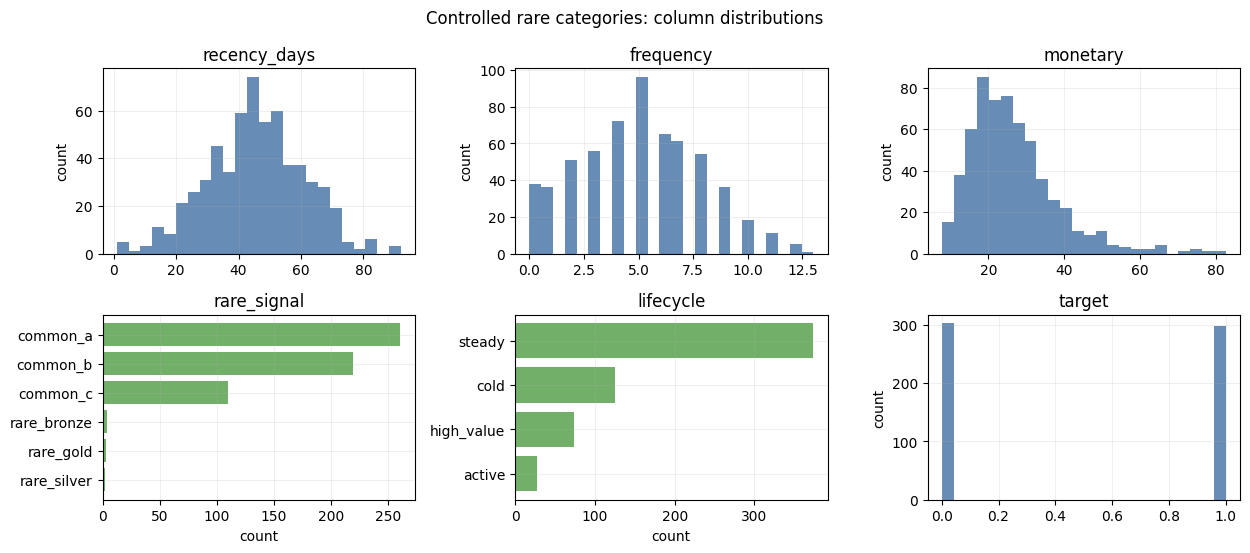

In [10]:
_ = plot_column_distributions(dataframe, title=EDA_CONFIG.title)

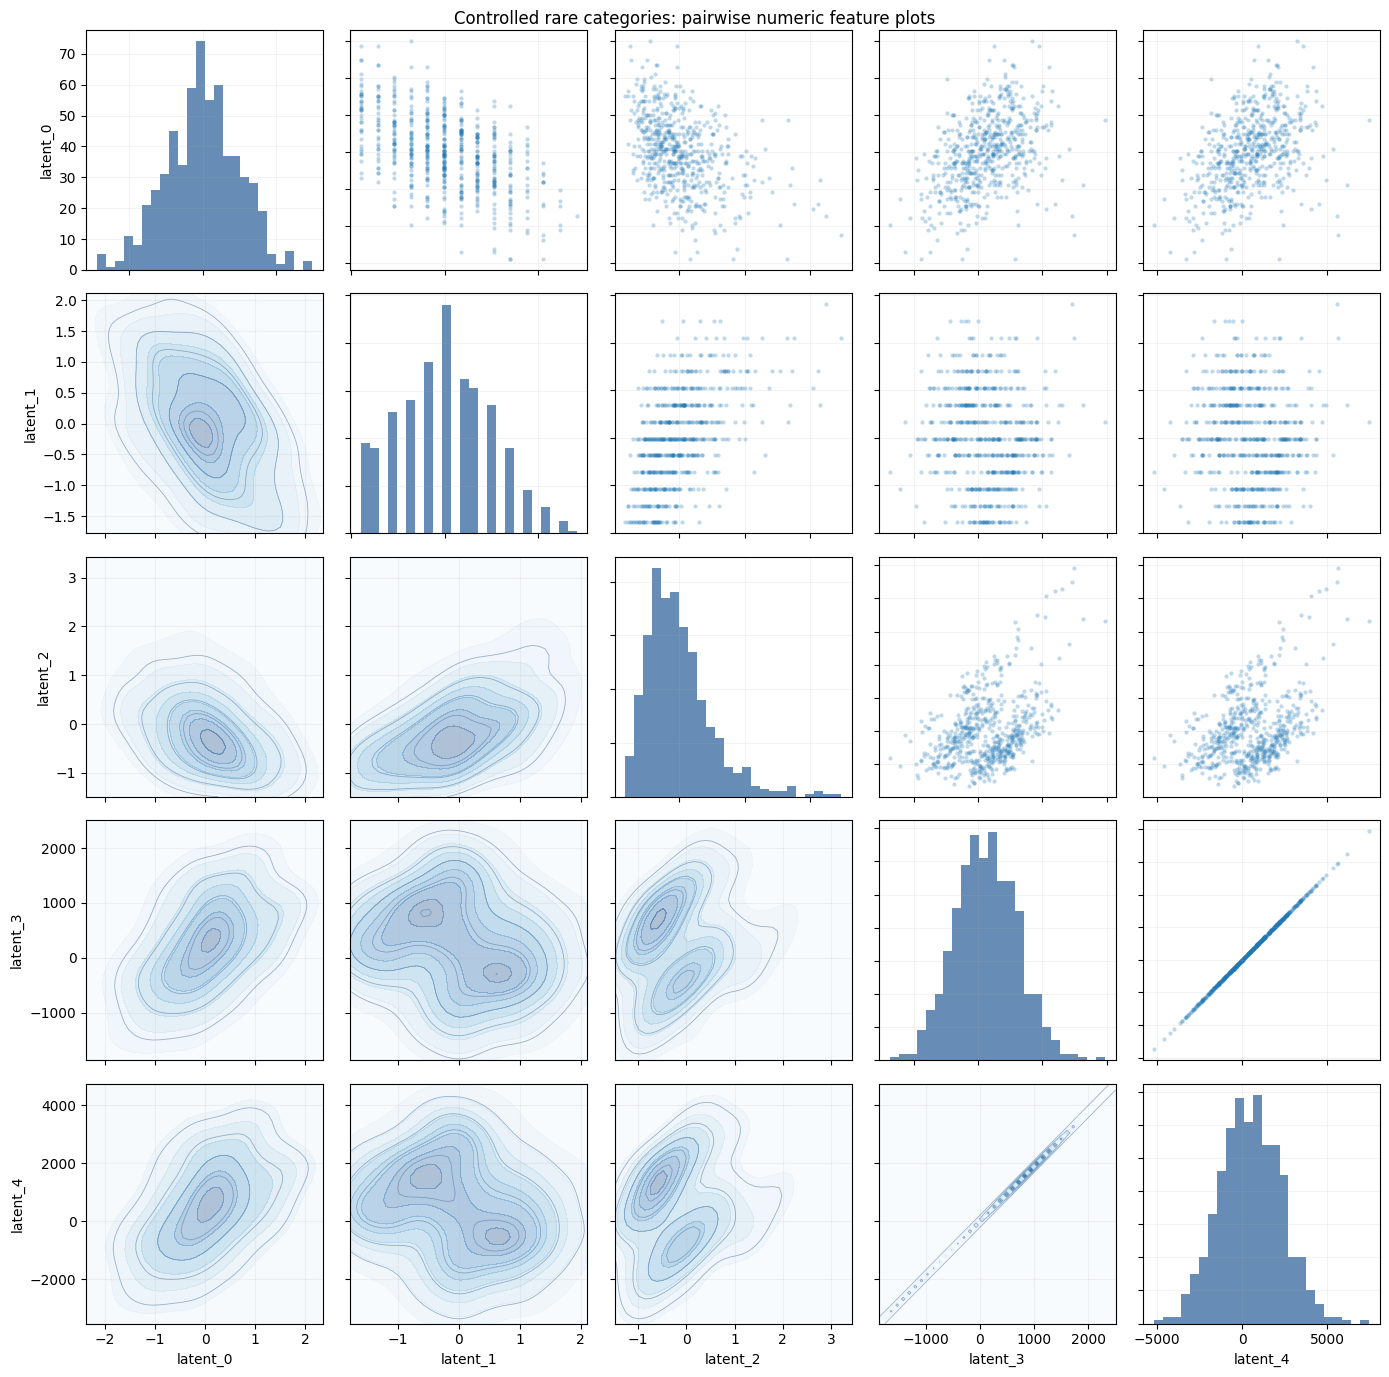

In [11]:
numeric_work = numeric_view_from_config(work, EDA_CONFIG)
_ = plot_pairwise_features(numeric_work, target_column=EDA_CONFIG.target_column, title=EDA_CONFIG.title)

## Run All Controlled Experiments

The sampler/baseline workflows run after the exploratory cells.


In [12]:
results = {
    key: run_configured_dataset_experiment(DATASET_CONFIGS[key], root=ROOT, results_dir=RESULTS_DIR)
    for key in SYNTHETIC_KEYS
}
list(results)


/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/src/dataframe_sampler/sampler.py:273: UserWarning: Categorical column 'patient_id' has 600 unique values. DataFrameSampler 2.0 will use it, but high-cardinality columns should usually be preprocessed deliberately.
  self._warn_high_cardinality(dataframe)
/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/src/dataframe_sampler/sampler.py:393: RuntimeWarning: Falling back to a constant latent block for categorical column 'patient_id' because NCA failed: The number of samples must be more than the number of classes.
  projector = self._fit_projector(column, context, labels)
/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/src/dataframe_sampler/sampler.py:393: RuntimeWarning: Falling back to a constant latent block for categorical column 'patient_id' because NCA failed: The number of samples must be more than the number

['synthetic_correlated_helpers',
 'synthetic_high_cardinality',
 'synthetic_rare_categories',
 'synthetic_sensitive_identifier']

## Numeric Projection Of Generated Data

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/figures/synthetic_rare_categories_numeric_projection.pdf')

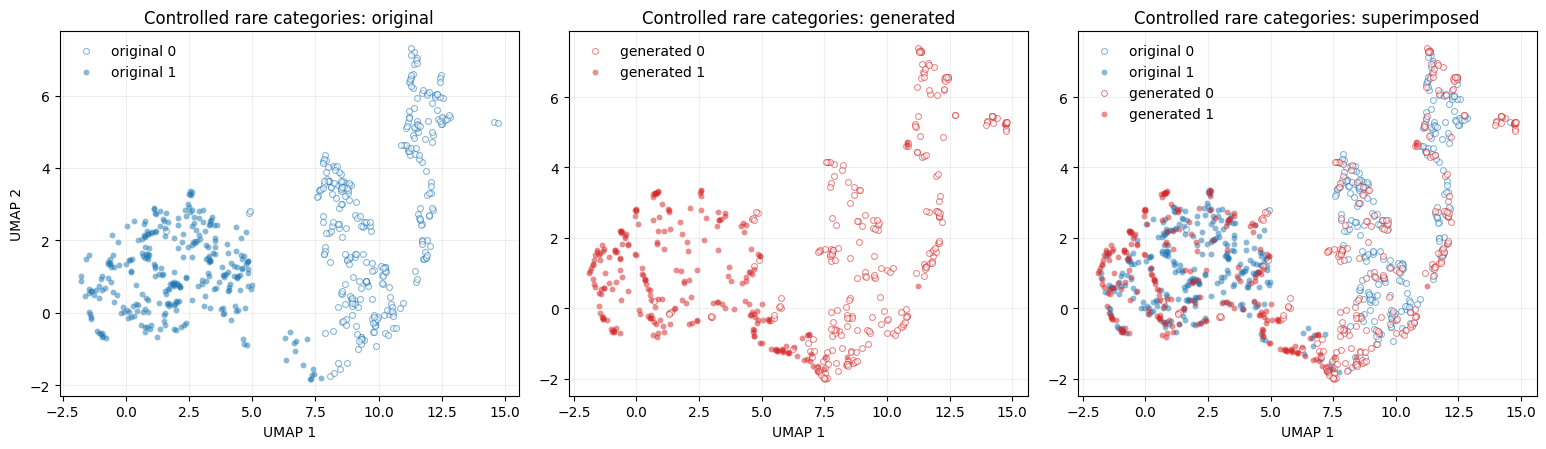

In [13]:
projection_result = results[EDA_KEY]
_ = plot_numeric_projection_triptych(
    projection_result.starter_run.sampler,
    projection_result.working_dataframe,
    projection_result.starter_run.generated,
    target_column=EDA_CONFIG.target_column,
    title=EDA_CONFIG.title,
    reducer="umap",
    random_state=EDA_CONFIG.random_state,
)


## Experiment Profiles


In [14]:
{key: result.dataframe.shape for key, result in results.items()}


{'synthetic_correlated_helpers': (600, 6),
 'synthetic_high_cardinality': (600, 7),
 'synthetic_rare_categories': (600, 6),
 'synthetic_sensitive_identifier': (600, 7)}

In [15]:
results["synthetic_rare_categories"].profile


,dtype,missing,unique
recency_days,int64,0,77
frequency,int64,0,14
monetary,float64,0,550
rare_signal,object,0,6
lifecycle,object,0,4
target,int64,0,2


## Comparison Summaries


In [16]:
pd.concat([result.comparison for result in results.values()], ignore_index=True)


,dataset,method,n_real,n_synthetic,numeric_mean_abs_error,numeric_std_abs_error,numeric_ks_statistic,numeric_wasserstein_distance,numeric_histogram_overlap,categorical_total_variation,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_numeric_kl,distribution_categorical_jsd,distribution_categorical_tv,distribution_similarity_score
0,synthetic_correlated_helpers,dataframe_sampler_default,600,500,0.192338,0.480623,0.039333,0.549935,0.924083,0.029167,...,0.842424,classification,0.905512,0.911023,0.005511,0.924083,0.111110,0.001008,0.029167,0.964636
1,synthetic_correlated_helpers,dataframe_sampler_manual,600,500,0.199745,0.350868,0.040833,0.497037,0.923417,0.027667,...,0.800000,classification,0.905512,0.911111,0.005600,0.923417,0.026983,0.000863,0.027667,0.964962
2,synthetic_correlated_helpers,gaussian_copula_empirical,600,500,0.289731,0.163486,0.035833,0.418519,0.949667,0.027500,...,0.212121,classification,0.905512,0.911023,0.005511,0.949667,0.081718,0.001020,0.027500,0.973715
3,synthetic_correlated_helpers,independent_columns,600,500,0.300050,0.084843,0.037167,0.409682,0.943833,0.034667,...,0.163636,classification,0.905512,0.905406,-0.000106,0.943833,0.103484,0.001139,0.034667,0.969343
4,synthetic_correlated_helpers,row_bootstrap,600,500,0.182588,0.150863,0.031250,0.323018,0.944333,0.020500,...,0.848485,classification,0.905512,0.933267,0.027755,0.944333,0.014089,0.000380,0.020500,0.974484
5,synthetic_correlated_helpers,stratified_columns,600,500,0.316698,0.164682,0.034417,0.410353,0.938167,0.026333,...,0.278788,classification,0.905512,0.916628,0.011116,0.938167,0.038221,0.000691,0.026333,0.970381
6,synthetic_high_cardinality,dataframe_sampler_default,600,500,0.679621,1.281822,0.065750,1.539363,0.907667,0.095778,...,0.800000,classification,0.988921,0.972340,-0.016581,0.907667,0.045801,0.018010,0.095778,0.931293
7,synthetic_high_cardinality,dataframe_sampler_manual,600,500,1.412948,1.313149,0.080250,1.809671,0.902417,0.088111,...,0.818182,classification,0.988921,0.972340,-0.016581,0.902417,0.092330,0.016130,0.088111,0.932725
8,synthetic_high_cardinality,gaussian_copula_empirical,600,500,0.398066,0.307827,0.046167,0.824091,0.927667,0.072222,...,0.418182,classification,0.988921,0.955089,-0.033832,0.927667,0.064763,0.011305,0.072222,0.948046
9,synthetic_high_cardinality,independent_columns,600,500,0.158129,0.203551,0.029250,0.398907,0.947333,0.065000,...,0.369697,classification,0.988921,0.983307,-0.005614,0.947333,0.101418,0.012410,0.065000,0.956641


In [17]:
pd.concat(
    [summarize_manifold_validation(result.manifold_validation) for result in results.values()],
    ignore_index=True,
)


,dataset,method,out_hull_rate,real_stress_median,real_stress_q95,generated_stress_median,out_hull_stress_median,out_hull_acceptance_at_real_q95
0,synthetic_correlated_helpers,dataframe_sampler_manual,0.584,0.004811,0.017164,0.003643,0.003749,0.952055
1,synthetic_correlated_helpers,latent_interpolation,0.000,0.004811,0.017164,0.005101,NaN,NaN
2,synthetic_high_cardinality,dataframe_sampler_manual,0.912,0.016129,0.034474,0.016963,0.017083,0.956140
3,synthetic_high_cardinality,latent_interpolation,0.000,0.016129,0.034474,0.016739,NaN,NaN
4,synthetic_rare_categories,dataframe_sampler_manual,0.488,0.017281,0.032119,0.016331,0.015800,0.918033
5,synthetic_rare_categories,latent_interpolation,0.000,0.017281,0.032119,0.016815,NaN,NaN
6,synthetic_sensitive_identifier,dataframe_sampler_manual,0.636,0.014708,0.024276,0.015093,0.014657,0.918239
7,synthetic_sensitive_identifier,latent_interpolation,0.000,0.014708,0.024276,0.014580,NaN,NaN


In [ ]:
summarize_mechanism_validation(
    pd.concat([result.mechanism_validation for result in results.values()], ignore_index=True)
)


In [ ]:
summarize_decoder_calibration(
    pd.concat([result.decoder_calibration for result in results.values()], ignore_index=True)
)


## Predictive Target Evaluation

For the selected `EDA_KEY`, the real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [18]:
predictive_report = predictive_performance_report(work, EDA_CONFIG)
predictive_report


,dataset,target_column,task,training_source,accuracy,balanced_accuracy,f1_weighted,roc_auc,mae,rmse,r2,train_rows,test_rows
0,synthetic_rare_categories,target,classification,real_train,0.977778,0.977899,0.977778,0.982467,NaN,NaN,NaN,420,180
1,synthetic_rare_categories,target,classification,synthetic_from_real_train,0.972222,0.972404,0.972220,0.982097,NaN,NaN,NaN,420,180
